In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import pandas as pd
import os

In [8]:
#Change to your work dir for DART EVAL
os.environ['DART_WORK_DIR'] = '/oak/stanford/groups/akundaje/arpitas/dart-eval/'
root_output_dir = os.environ.get("DART_WORK_DIR", "")

In [9]:
#Replace this with your path for task results
aggregated_table = "/mnt/lab_data2/regulatory_lm/scratch/transformer_test/run_20251231_230449/dart_eval_task_2/regulatory_lm.tsv"
agg_data = pd.read_csv(aggregated_table, sep="\t", index_col=0)


In [10]:
motif_family_file = os.path.join(root_output_dir,"task_2_footprinting/input_data/H12CORE_motifs.tsv")
motif_family_data = pd.read_csv(motif_family_file, sep="\t", index_col=0)
agg_data["Family"] = motif_family_data["TF family"]

In [16]:
#Get percentage of motifs above 70% accuracy
high_acc_motifs = (agg_data["Accuracy"] > 0.7).sum() / len(agg_data["Accuracy"])
print(high_acc_motifs)

0.6036036036036037


Text(0, 0.5, 'Motif Count')

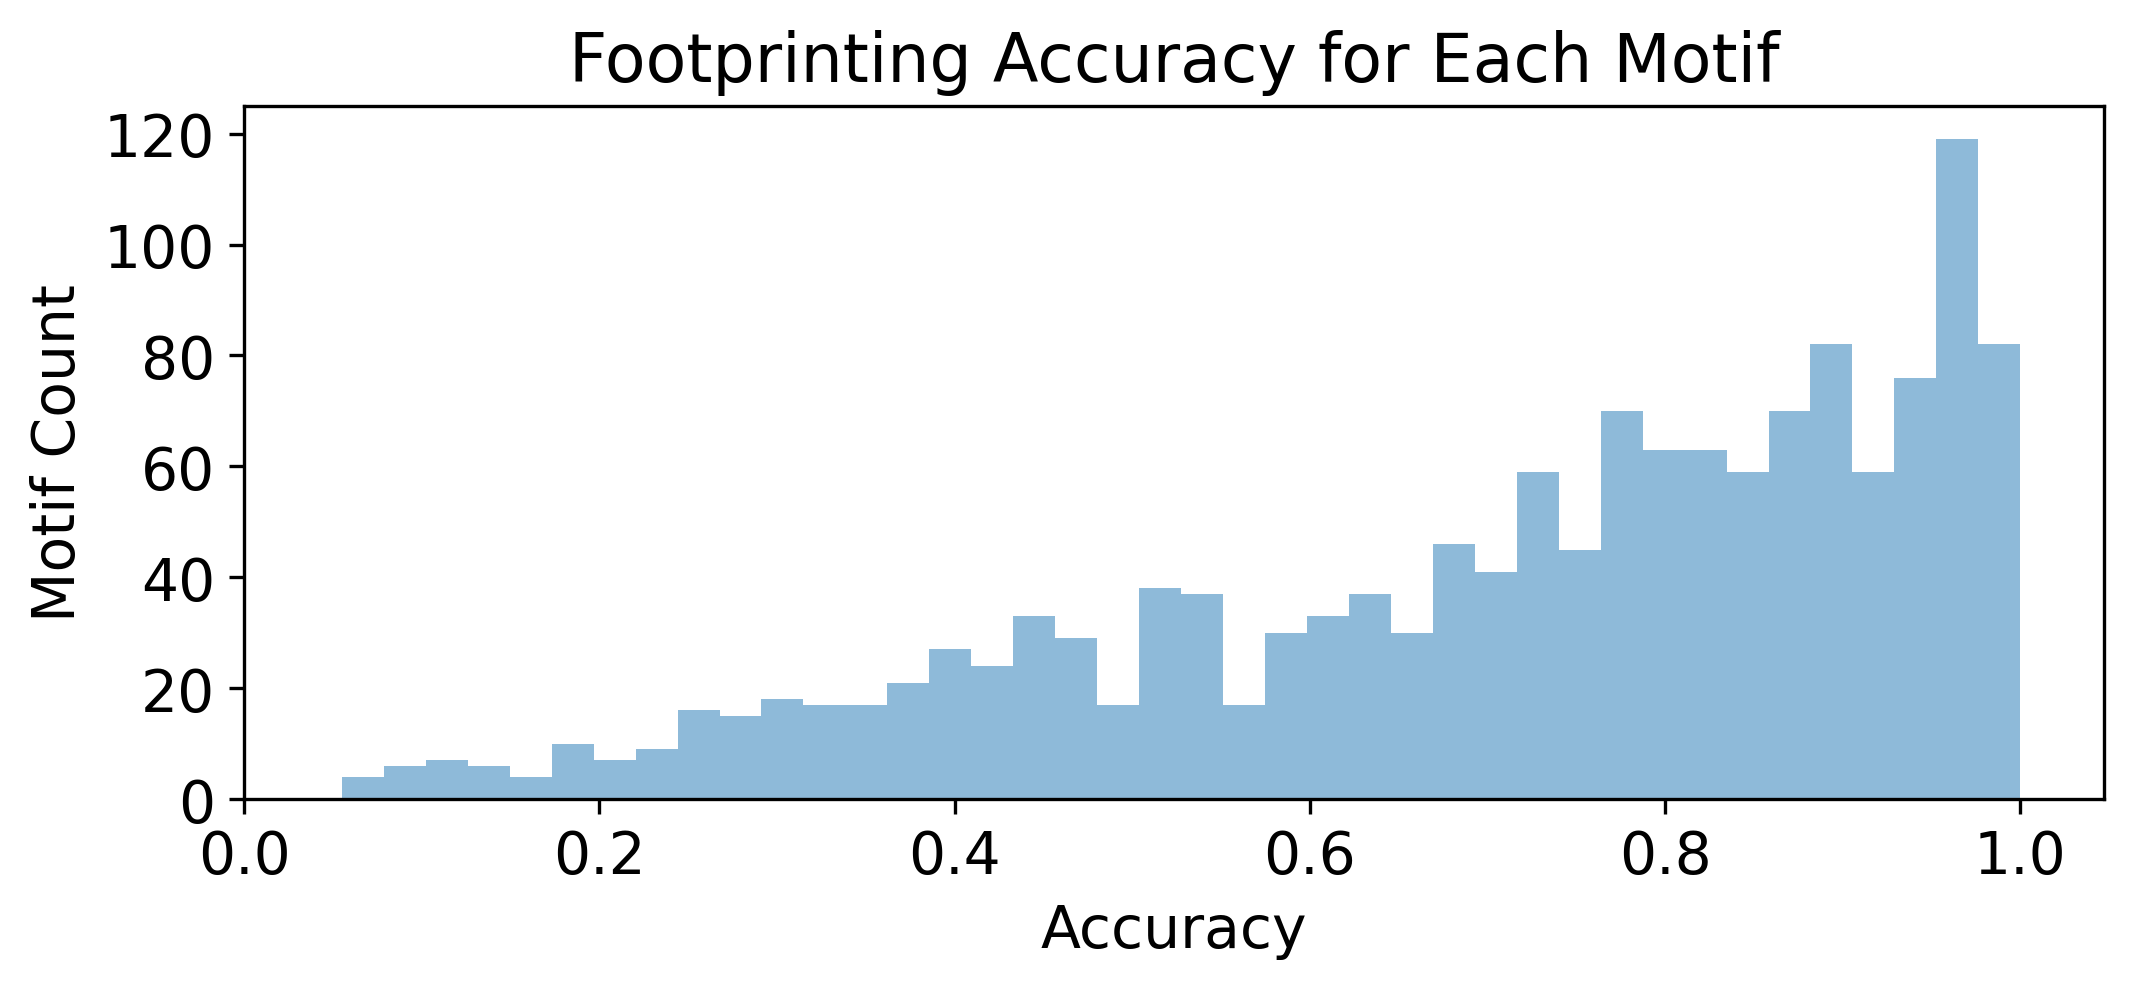

In [12]:
plt.figure(dpi=300, figsize=[8,3])
plt.hist(agg_data["Accuracy"], bins=40, alpha=0.5)
plt.title("Footprinting Accuracy for Each Motif", fontsize=16)
plt.xlabel("Accuracy", fontsize=14)
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1], fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Motif Count", fontsize=14)

In [13]:
family_acc_means = agg_data.groupby("Family")["Accuracy"].mean()
family_acc_vars = agg_data.groupby("Family")["Accuracy"].apply(lambda x: np.var(x))


In [14]:
mean_order = family_acc_means.sort_values().index.values

In [15]:
acc_vals, acc_labels, lengths = [], [], []
for family in mean_order:
    cur_accs = agg_data.loc[agg_data["Family"] == family]["Accuracy"].values
    if len(cur_accs) < 10:
        continue
    acc_vals.append(cur_accs)
    lengths.append(len(cur_accs))
    acc_labels.append(family.split(" {")[0] + f" ({len(cur_accs)})")

In [ ]:
plt.figure(dpi=300, figsize=[8,16])
plt.boxplot(acc_vals, vert=False, labels=acc_labels)
plt.title("ARSENAL Performance on Motif Families", fontsize=16)
plt.xlabel("Accuracy", fontsize=14)
plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.ylabel("Family (Motif Count)", fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [ ]:
np.quantile(agg_data["Accuracy"], 0), np.quantile(agg_data["Accuracy"], 0.25), np.quantile(agg_data["Accuracy"], 0.5), np.quantile(agg_data["Accuracy"], 0.75), np.quantile(agg_data["Accuracy"], 1)




In [36]:
mean_order

array(['PD {3.2.2}', 'GMEB {5.3.3}', 'Dbp {9.1.1}', 'LRRFIP {0.3.1}',
       'GCM {7.2.1}', 'C/EBP-related {1.1.8}', 'Myb/SANT domain {3.5.1}',
       'HOX-related {3.1.1}', 'NFAT-related {6.1.3}',
       'BED zinc finger {2.3.5}', 'E2F {3.3.2}',
       'Other with up to three adjacent zinc fingers {2.3.2}',
       'PD+HD {3.2.1}', 'Paired-related HD {3.1.3}',
       'XBP1-related {1.1.5}', 'C4-GATA-related {2.2.1}',
       'HD-LIM {3.1.5}', 'MYT {2.7.1}', 'Grainyhead-related {6.7.1}',
       'HD-CUT {3.1.9}', 'HSF {3.4.1}', 'HD-SINE {3.1.6}',
       'NK-related {3.1.2}', 'HMGA {8.2.1}', 'Unannotated {0.0.9}',
       'B-ATF-related {1.1.4}', 'ARID-related {3.7.1}',
       'ATF4-related {1.1.6}', 'CSL-related {6.1.4}', 'DMRT {2.5.1}',
       'TBP-related {8.1.1}', 'Ets-related {3.5.2}', 'HD-PROS {3.1.7}',
       'THAP {2.9.1}', 'SOX-related {4.1.1}', 'Fos-related {1.1.2}',
       'Maf-related {1.1.3}', 'POU {3.1.10}', 'Runt-related {6.4.1}',
       'FOX {3.3.1}', 'PAS {1.2.5}',
       '

In [37]:
(agg_data["Accuracy"] > 0.5).values.sum()

1052